In [1]:
import numpy as np
import matplotlib.pyplot as plt

(-0.5, 511.5, 511.5, -0.5)

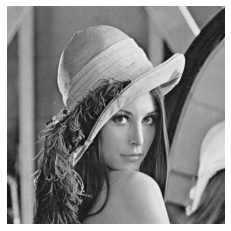

In [3]:
img = plt.imread('1.jpg')
img = np.mean(img, axis=2).astype(np.uint8)
plt.imshow(img, cmap="gray")
plt.axis("off")

### Histogram Equalisation

In [22]:
flat = img.flatten()
hist, _ = np.histogram(flat, bins=256, range=(0, 256))
cdf = hist.cumsum()
cdf_min = cdf[cdf > 0].min()
cdf_normalised = np.round((cdf - cdf_min) * 255 / (cdf.max() - cdf_min)).astype(np.uint8)
equalised = cdf_normalised[flat].reshape(img.shape)

(-0.5, 511.5, 511.5, -0.5)

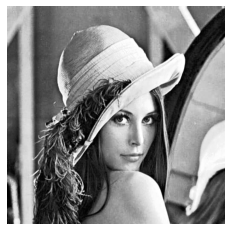

In [23]:
plt.imshow(equalised, cmap='gray')
plt.axis('off')

### Histogram Specification

(-0.5, 511.5, 511.5, -0.5)

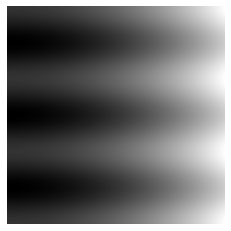

In [16]:
h, w = img.shape
x, y = np.linspace(0, 1, w), np.linspace(0, 1, h)
X, Y = np.meshgrid(x, y)

target = (0.1 + 0.8 * X ** 2 + 0.1 * np.cos(2 * np.pi * Y * 3)).clip(0, 1)
target = (target * 255).astype(np.uint8)
plt.imshow(target, cmap='gray')
plt.axis('off')

In [18]:
flat_src = img.flatten()
flat_ref = target.flatten()
hist_src, _ = np.histogram(flat_src, bins=256, range=(0, 256))
hist_ref, _ = np.histogram(flat_ref, bins=256, range=(0, 256))
cdf_src = hist_src.cumsum().astype(float)
cdf_ref = hist_ref.cumsum().astype(float)
mapping = np.interp(cdf_src, cdf_ref, np.arange(256)).astype(np.uint8)
matched = mapping[flat_src].reshape(img.shape)

(-0.5, 511.5, 511.5, -0.5)

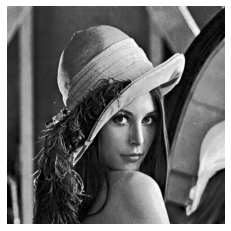

In [19]:
plt.imshow(matched, cmap='gray')
plt.axis('off')

### CLAHE

In [24]:
import cv2 as cv

(-0.5, 511.5, 511.5, -0.5)

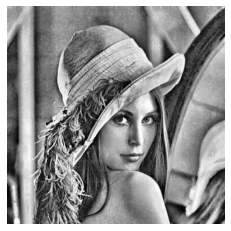

In [32]:
c = cv.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
cl1 = c.apply(img)
plt.imshow(cl1, cmap='gray')
plt.axis('off')

In [33]:
def interpolate(subBin, LU, RU, LB, RB, subX, subY):
    subImage = np.zeros(subBin.shape)
    num = subX * subY
    for i in range(subX):
        inverseI = subX - i
        for j in range(subY):
            inverseJ = subY - j
            val = subBin[i, j].astype(int)
            subImage[i, j] = np.floor((inverseI * (inverseJ * LU[val] + j * RU[val]) +
                                       i * (inverseJ * LB[val] + j * RB[val])) / float(num))
    return subImage

In [34]:
def clahe(img, clipLimit, nrBins=128, nrX=0, nrY=0):
    h, w = img.shape
    if clipLimit == 1:
        return img.copy()                    
    
    nrBins = max(nrBins, 128)
    excX = 0
    excY = 0
    
    if nrX == 0:                      
        xsz = ysz = 32
        nrX = int(np.ceil(h / xsz))
        nrY = int(np.ceil(w / ysz))
        excX = int(xsz * (nrX - h / xsz))
        excY = int(ysz * (nrY - w / ysz))
        if excX != 0:
            img = np.append(img, np.zeros((excX, img.shape[1]), dtype=int), axis=0)
        if excY != 0:
            img = np.append(img, np.zeros((img.shape[0], excY), dtype=int), axis=1)
    else:
        xsz = round(h / nrX)
        ysz = round(w / nrY)
    
    nrPixels = xsz * ysz
    claheimg = np.zeros(img.shape, dtype=float)
    
    if clipLimit > 0:
        clipLimit = max(1, clipLimit * nrPixels / nrBins)
    else:
        clipLimit = 50
    
    minVal, maxVal = 0, 255
    binSz = np.floor(1 + (maxVal - minVal) / float(nrBins))
    LUT = np.floor((np.arange(minVal, maxVal + 1) - minVal) / binSz)
    
    bins = LUT[img].astype(int)
    
    hist = np.zeros((nrX, nrY, nrBins))
    for i in range(nrX):
        for j in range(nrY):
            tile = bins[i * xsz:(i + 1) * xsz, j * ysz:(j + 1) * ysz]
            for ii in range(xsz):
                for jj in range(ysz):
                    hist[i, j, tile[ii, jj]] += 1
    
    for i in range(nrX):
        for j in range(nrY):
            nrExcess = 0
            for nr in range(nrBins):
                excess = hist[i, j, nr] - clipLimit
                if excess > 0:
                    nrExcess += excess
            binIncr = nrExcess / nrBins
            upper = clipLimit - binIncr
            for nr in range(nrBins):
                if hist[i, j, nr] > clipLimit:
                    hist[i, j, nr] = clipLimit
                elif hist[i, j, nr] > upper:
                    nrExcess += upper - hist[i, j, nr]
                    hist[i, j, nr] = clipLimit
                else:
                    nrExcess -= binIncr
                    hist[i, j, nr] += binIncr
            if nrExcess > 0:
                stepSz = max(1, int(1 + nrExcess / nrBins))
                for nr in range(nrBins):
                    nrExcess -= stepSz
                    hist[i, j, nr] += stepSz
                    if nrExcess < 1:
                        break
    
    map_ = np.zeros((nrX, nrY, nrBins))
    scale = (maxVal - minVal) / float(nrPixels)
    for i in range(nrX):
        for j in range(nrY):
            sum_ = 0
            for nr in range(nrBins):
                sum_ += hist[i, j, nr]
                map_[i, j, nr] = np.floor(min(minVal + sum_ * scale, maxVal))
    
    xI = 0
    for i in range(nrX + 1):
        if i == 0:
            subX = int(xsz / 2)
            xU = xB = 0
        elif i == nrX:
            subX = int(xsz / 2)
            xU = xB = nrX - 1
        else:
            subX = xsz
            xU = i - 1
            xB = i
        yI = 0
        for j in range(nrY + 1):
            if j == 0:
                subY = int(ysz / 2)
                yL = yR = 0
            elif j == nrY:
                subY = int(ysz / 2)
                yL = yR = nrY - 1
            else:
                subY = ysz
                yL = j - 1
                yR = j
            UL = map_[xU, yL, :]
            UR = map_[xU, yR, :]
            BL = map_[xB, yL, :]
            BR = map_[xB, yR, :]
            subBin = bins[xI:xI + subX, yI:yI + subY]
            subImage = interpolate(subBin, UL, UR, BL, BR, subX, subY)
            claheimg[xI:xI + subX, yI:yI + subY] = subImage
            yI += subY
        xI += subX
    
    if excX == 0 and excY != 0:
        return claheimg[:, :-excY].astype(np.uint8)
    elif excX != 0 and excY == 0:
        return claheimg[:-excX, :].astype(np.uint8)
    elif excX != 0 and excY != 0:
        return claheimg[:-excX, :-excY].astype(np.uint8)
    else:
        return claheimg.astype(np.uint8)

In [35]:
img_clahe = clahe(img.copy(), clipLimit=4.0, nrBins=256, nrX=0, nrY=0)

(-0.5, 511.5, 511.5, -0.5)

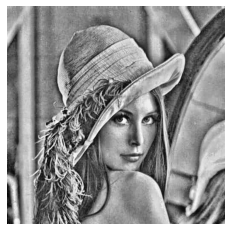

In [37]:
plt.imshow(img_clahe, cmap='gray')
plt.axis('off')